In [ ]:
## Day 10 - Regression - House Price Prediction

What I learned today:
- Regression predicts numbers, Classification predicts yes/no
- Linear Regression breaks at extremes — predicted negative price!
- MAE = average distance between actual and predicted values
- Random Forest handled extremes better — $2,769 vs $3,333 MAE
- Dots close to red line = accurate model
- One blue dot was below zero = impossible negative house price

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

print("Day 10 - Regression - House Price Prediction")

df = pd.read_csv("https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv")
print("Shape:", df.shape)
df.head()

Day 10 - Regression - House Price Prediction
Shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [3]:
print(df.isnull().sum())
print("What are we predicting")
print(df['medv'].describe())

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64
What are we predicting
count    506.000000
mean      22.532806
std        9.197104
min        5.000000
25%       17.025000
50%       21.200000
75%       25.000000
max       50.000000
Name: medv, dtype: float64


In [6]:
# X = inputs (what we know about the house)
# y = output (price we want to predict)
X = df[["rm", "lstat", "ptratio"]]
y = df["medv"]
print("Input Shape: ", X)
print("target Shape: ", y)

Input Shape:          rm  lstat  ptratio
0    6.575   4.98     15.3
1    6.421   9.14     17.8
2    7.185   4.03     17.8
3    6.998   2.94     18.7
4    7.147   5.33     18.7
..     ...    ...      ...
501  6.593   9.67     21.0
502  6.120   9.08     21.0
503  6.976   5.64     21.0
504  6.794   6.48     21.0
505  6.030   7.88     21.0

[506 rows x 3 columns]
target Shape:  0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: medv, Length: 506, dtype: float64


In [8]:
# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 42)
print("Training houses:", len(X_train))
print("Testing houses: ", len(X_test))

Training houses: 404
Testing houses:  102


In [9]:
model = LinearRegression()
model.fit(X_train, y_train)
print("model trained!!")

model trained!!


In [10]:
# Predict prices for the 102 hidden test houses
predictions = model.predict(X_test)
# Measure how wrong we are on average
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error: ${mae*1000:.0f}")
print()

# See actual vs predicted side by side
comparison = pd.DataFrame({
    "Actual Price":    y_test.values[:10],
    "Predicted Price": predictions[:10].round(1)
})
print(comparison)

Mean Absolute Error: $3333

   Actual Price  Predicted Price
0          23.6             26.7
1          32.4             30.7
2          13.6             16.4
3          22.8             24.7
4          16.1             18.3
5          20.0             22.6
6          17.8             17.4
7          14.0             13.0
8          19.6             20.5
9          16.8             19.5


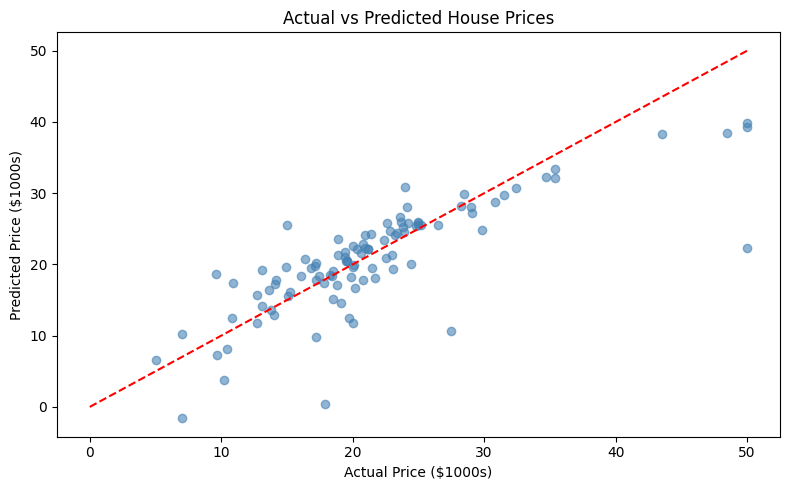

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, color="steelblue", alpha=0.6)
plt.plot([0, 50], [0, 50], color="red", linestyle="--")
plt.xlabel("Actual Price ($1000s)")
plt.ylabel("Predicted Price ($1000s)")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.show()

In [16]:
# Let's predict ONE house manually
# [rm, lstat, ptratio]
# 6 rooms, 5% poor area, school ratio 15

my_house = pd.DataFrame([[9.0, 45.0, 15.0]], 
                         columns=["rm", "lstat", "ptratio"])

predicted_price = model.predict(my_house)
print(f"My house prediction: ${predicted_price[0]*1000:.0f}")

My house prediction: $20459


In [17]:
luxury = pd.DataFrame([[8.0, 1.0, 12.0]], 
                       columns=["rm", "lstat", "ptratio"])
print("Luxury house:", f"${model.predict(luxury)[0]*1000:.0f}")

Luxury house: $43081


In [18]:
poor_area = pd.DataFrame([[4.0, 30.0, 20.0]], 
                          columns=["rm", "lstat", "ptratio"])
print("Poor area house:", f"${model.predict(poor_area)[0]*1000:.0f}")

Poor area house: $-35


In [19]:
average = pd.DataFrame([[6.0, 10.0, 16.0]], 
                        columns=["rm", "lstat", "ptratio"])
print("Average house:", f"${model.predict(average)[0]*1000:.0f}")

Average house: $24642


In [20]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest on same data
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# Compare MAE
rf_mae = mean_absolute_error(y_test, rf_predictions)
lr_mae = mean_absolute_error(y_test, predictions)

print(f"Linear Regression MAE:  ${lr_mae*1000:.0f}")
print(f"Random Forest MAE:      ${rf_mae*1000:.0f}")
print()

# Test poor area house with Random Forest
print("Poor area house (Linear Regression):", f"${model.predict(poor_area)[0]*1000:.0f}")
print("Poor area house (Random Forest):    ", f"${rf_model.predict(poor_area)[0]*1000:.0f}")

Linear Regression MAE:  $3333
Random Forest MAE:      $2769

Poor area house (Linear Regression): $-35
Poor area house (Random Forest):     $9734


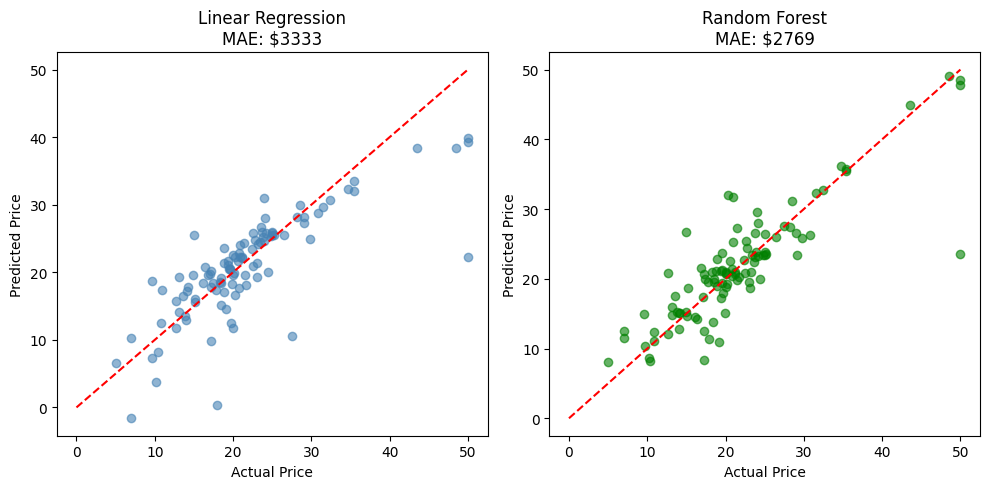

In [21]:
plt.figure(figsize=(10, 5))

# Linear Regression plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, predictions, color="steelblue", alpha=0.6)
plt.plot([0, 50], [0, 50], color="red", linestyle="--")
plt.title(f"Linear Regression\nMAE: ${lr_mae*1000:.0f}")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

# Random Forest plot
plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_predictions, color="green", alpha=0.6)
plt.plot([0, 50], [0, 50], color="red", linestyle="--")
plt.title(f"Random Forest\nMAE: ${rf_mae*1000:.0f}")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()